# HMM A/B exploratorio: retorno, volatilidad y skew

Este cuaderno ejecuta y revisa el primer análisis HMM definido en v3. **Todo 2020–2026 es exploratorio y retrospectivo**: 2024–2026 ya se observó, no es una prueba prospectiva ni una integración con Actinver.

A usa retorno log y `vol20`; B añade skew. Las probabilidades están filtradas cronológicamente, pero los parámetros del ajuste final usan el historial completo; por ello no representan una señal que hubiera estado congelada en tiempo real.

In [1]:
from pathlib import Path
import sys, subprocess, json
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
print(ROOT)
result = subprocess.run([sys.executable, 'scripts/hmm_exploratory_ab.py'], cwd=ROOT, text=True, capture_output=True)
print(result.stdout)
if result.stderr: print('Advertencias registradas:\n' + result.stderr)
assert result.returncode == 0, result.stderr
REPORTS = ROOT / 'reports'

C:\Users\avazq\OneDrive\Escritorio\cienciadatos\portafolio\quant-research-notes\HMM_regime_options


{
  "preflight": {
    "passed": true,
    "rows": 3,
    "missing_skew_row": 1,
    "marginalized_dimensions": [
      "return",
      "vol20"
    ],
    "transition_advanced": true,
    "b_alert_suppressed": true
  },
  "selected_seeds": {
    "A": 4,
    "B": 5
  },
  "threshold_A": 0.9848322606605292,
  "threshold_B": 0.9728030900994156,
  "rows": 1673
}

Advertencias registradas:
C:\Users\avazq\OneDrive\Escritorio\cienciadatos\portafolio\quant-research-notes\HMM_regime_options\scripts\hmm_exploratory_ab.py:108: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  f["expiry_change"] = op.expiry_change.fillna(False).reindex(f.index, fill_value=False)
C:\Users\avazq\OneDrive\Escritorio\cienciadatos\portafolio\quant-research-notes\HMM_regime_options\scripts\hmm_exploratory_ab

## 1. Prueba previa: skew faltante

Antes del ajuste, el script usa una serie sintética de tres sesiones. En la sesión central falta skew: la verosimilitud usa solo retorno y `vol20`, el filtro avanza la transición, conserva la sesión y B no emite alerta. Si esto fallara, el análisis se detendría.

In [2]:
preflight = json.loads((REPORTS / 'hmm_ab_preflight.json').read_text())
preflight

{'passed': True,
 'rows': 3,
 'missing_skew_row': 1,
 'marginalized_dimensions': ['return', 'vol20'],
 'transition_advanced': True,
 'b_alert_suppressed': True}

Interpretación: `passed=True` confirma la propiedad requerida de marginalización en la implementación usada. Es una prueba unitaria pequeña, no una validación independiente completa del algoritmo EM.

## 2. Datos, cobertura y calidad

`vol20` usa 20 retornos log hasta el cierre de la sesión observada. La probabilidad predictiva se fecha en la siguiente sesión de decisión. B conserva las filas sin skew internamente, aunque allí no puede emitir alerta.

In [3]:
import pandas as pd
coverage = pd.read_csv(REPORTS / 'hmm_ab_coverage.csv')
scaler = pd.read_csv(REPORTS / 'hmm_ab_scaler.csv')
display(coverage.T.rename(columns={0:'conteo'}))
display(scaler)

,conteo
calendar_rows_return_vol20,1654
B_rows_retained_with_missing_skew,1654
B_alert_available,1652
B_alert_unavailable_missing_skew,1
common_alert_dates,1652
quality_wide_spread,8
quality_expiry_change,639
quality_extreme_jump,12
quality_any,653


,feature,development_mean,development_std,n_development_observed
0,return,0.000442,0.014417,986
1,vol20,0.012020,0.008062,986
2,skew,0.075125,0.036551,985


Interpretación: las pérdidas de cobertura B se separan de las banderas `wide_spread`, cambio de vencimiento y salto extremo. Las banderas no excluyen filas en el análisis base; requieren sensibilidad futura, no una eliminación retrospectiva.

## 3. Ajuste reproducible

Las constantes de escalamiento se estiman solo con desarrollo 2020–2023. Las semillas 0…9 se comparan por log-verosimilitud de desarrollo; se conserva la mejor, sin mirar métricas de alertas. Luego se hace un ajuste exploratorio con todo el historial usando esa semilla fija.

In [4]:
seeds = pd.read_csv(REPORTS / 'hmm_ab_seed_convergence.csv')
display(seeds)
print('Fallos de ajuste:', int(seeds.failed.sum()), 'de', len(seeds))
display(pd.read_csv(REPORTS / 'hmm_ab_emissions.csv'))
display(pd.read_csv(REPORTS / 'hmm_ab_transitions.csv'))

,model,seed,loglik_development,n_iter,converged,failed
0,A,0,-1875.482303,20,True,False
1,A,1,-1875.482465,21,True,False
2,A,2,-1875.482185,21,True,False
3,A,3,-1875.482621,20,True,False
4,A,4,-1875.482062,6,True,False
5,A,5,-1875.482511,17,True,False
6,A,6,-1875.482459,22,True,False
7,A,7,-1875.482538,8,True,False
8,A,8,-1875.482133,14,True,False
9,A,9,-1875.482582,20,True,False


Fallos de ajuste: 0 de 20


,model,state,is_risk_state,development_risk_state,mapping_development_to_full,pi,mean_z_return,sd_z_return,mean_z_vol20,sd_z_vol20,mean_z_skew,sd_z_skew
0,A,0,True,0,"{""0"": 0, ""1"": 1}",1.000000e-08,-0.015069,1.393605,0.715316,1.177492,NaN,NaN
1,A,1,False,0,"{""0"": 0, ""1"": 1}",1.000000e+00,0.019087,0.542396,-0.538013,0.232188,NaN,NaN
2,B,0,True,1,"{""0"": 1, ""1"": 0}",1.000000e-08,-0.057591,1.488584,0.812726,1.263424,0.607211,1.213992
3,B,1,False,1,"{""0"": 1, ""1"": 0}",1.000000e+00,0.031229,0.549792,-0.493501,0.274594,-0.558349,0.561467


,model,from_state,to_state,probability
0,A,0,0,0.984832
1,A,0,1,0.015168
2,A,1,0,0.006415
3,A,1,1,0.993585
4,B,0,0,0.972803
5,B,0,1,0.027197
6,B,1,0,0.009118
7,B,1,1,0.990882


Interpretación: el estado llamado «mayor volatilidad» se fija con el ajuste de desarrollo y se alinea al ajuste completo por cercanía de medias. Es una etiqueta descriptiva: no significa por sí misma que prediga una caída.

## 4. Filtro y probabilidad predictiva

`*_filtered_risk` usa observaciones hasta la fecha de observación. `*_predictive_risk_next` aplica después la transición y se indexa por la siguiente fecha de decisión. Cuando el skew de la observación falta, B conserva su probabilidad interna pero `B_alert_available=False`.

In [5]:
daily = pd.read_csv(REPORTS / 'hmm_ab_daily.csv', parse_dates=['decision_date','observation_date']).set_index('decision_date')
cols = ['observation_date','adjusted_close','skew','A_filtered_risk','A_predictive_risk_next','B_filtered_risk','B_predictive_risk_next','A_alert_available','B_alert_available','quality_flag']
display(daily[cols].dropna(subset=['A_predictive_risk_next']).head(8))
diff = daily.assign(abs_difference=(daily.B_predictive_risk_next-daily.A_predictive_risk_next).abs()).dropna(subset=['abs_difference']).nlargest(8,'abs_difference')
display(diff[cols + ['abs_difference']])

,observation_date,adjusted_close,skew,A_filtered_risk,A_predictive_risk_next,B_filtered_risk,B_predictive_risk_next,A_alert_available,B_alert_available,quality_flag
decision_date,,,,,,,,,,
2020-02-03,2020-01-31,292.362242,0.05853,5.459912e-09,0.006415,1.960524e-09,0.009118,True,True,True
2020-02-04,2020-02-03,294.534081,0.07805,3.763044e-04,0.006783,4.440851e-04,0.009546,True,True,True
2020-02-05,2020-02-04,299.023154,0.04878,1.373848e-03,0.007759,4.761176e-04,0.009576,True,True,True
2020-02-06,2020-02-05,302.476288,0.04878,9.122420e-04,0.007307,2.719256e-04,0.009380,True,True,False
2020-02-07,2020-02-06,303.494053,0.05854,4.028719e-04,0.006809,1.581651e-04,0.009270,True,True,False
2020-02-10,2020-02-07,301.876533,0.05854,4.713542e-04,0.006876,2.018820e-04,0.009312,True,True,True
2020-02-11,2020-02-10,304.130157,0.05854,5.102663e-04,0.006914,2.042231e-04,0.009314,True,True,True
2020-02-12,2020-02-11,304.657214,0.05854,3.677190e-04,0.006774,1.523582e-04,0.009264,True,True,True


,observation_date,adjusted_close,skew,A_filtered_risk,A_predictive_risk_next,B_filtered_risk,B_predictive_risk_next,A_alert_available,B_alert_available,quality_flag,abs_difference
decision_date,,,,,,,,,,,
2021-12-06,2021-12-03,424.015429,0.13658,0.001236,0.007624,0.999731,0.972545,True,True,True,0.964920
2026-04-16,2026-04-15,696.433308,0.04878,0.990732,0.975764,0.002905,0.011918,True,True,False,0.963847
2021-12-02,2021-12-01,421.284793,0.13658,0.002066,0.008436,0.999375,0.972201,True,True,True,0.963765
2021-12-03,2021-12-02,427.737323,0.12683,0.002527,0.008887,0.999320,0.972148,True,True,False,0.963260
2022-08-04,2022-08-03,391.828619,0.05854,0.995848,0.980770,0.008919,0.017713,True,True,True,0.963057
2022-12-28,2022-12-27,363.758413,0.02927,0.995688,0.980614,0.008844,0.017641,True,True,True,0.962973
2022-08-15,2022-08-12,403.788160,0.03902,0.990866,0.975896,0.004384,0.013342,True,True,True,0.962553
2023-01-12,2023-01-11,377.225295,0.03902,0.988708,0.973784,0.002715,0.011734,True,True,False,0.962051


Interpretación: los ejemplos muestran diferencias de probabilidad condicionadas al ajuste exploratorio. No identifican causalidad del skew ni autorizan escoger nuevas variables o umbrales.

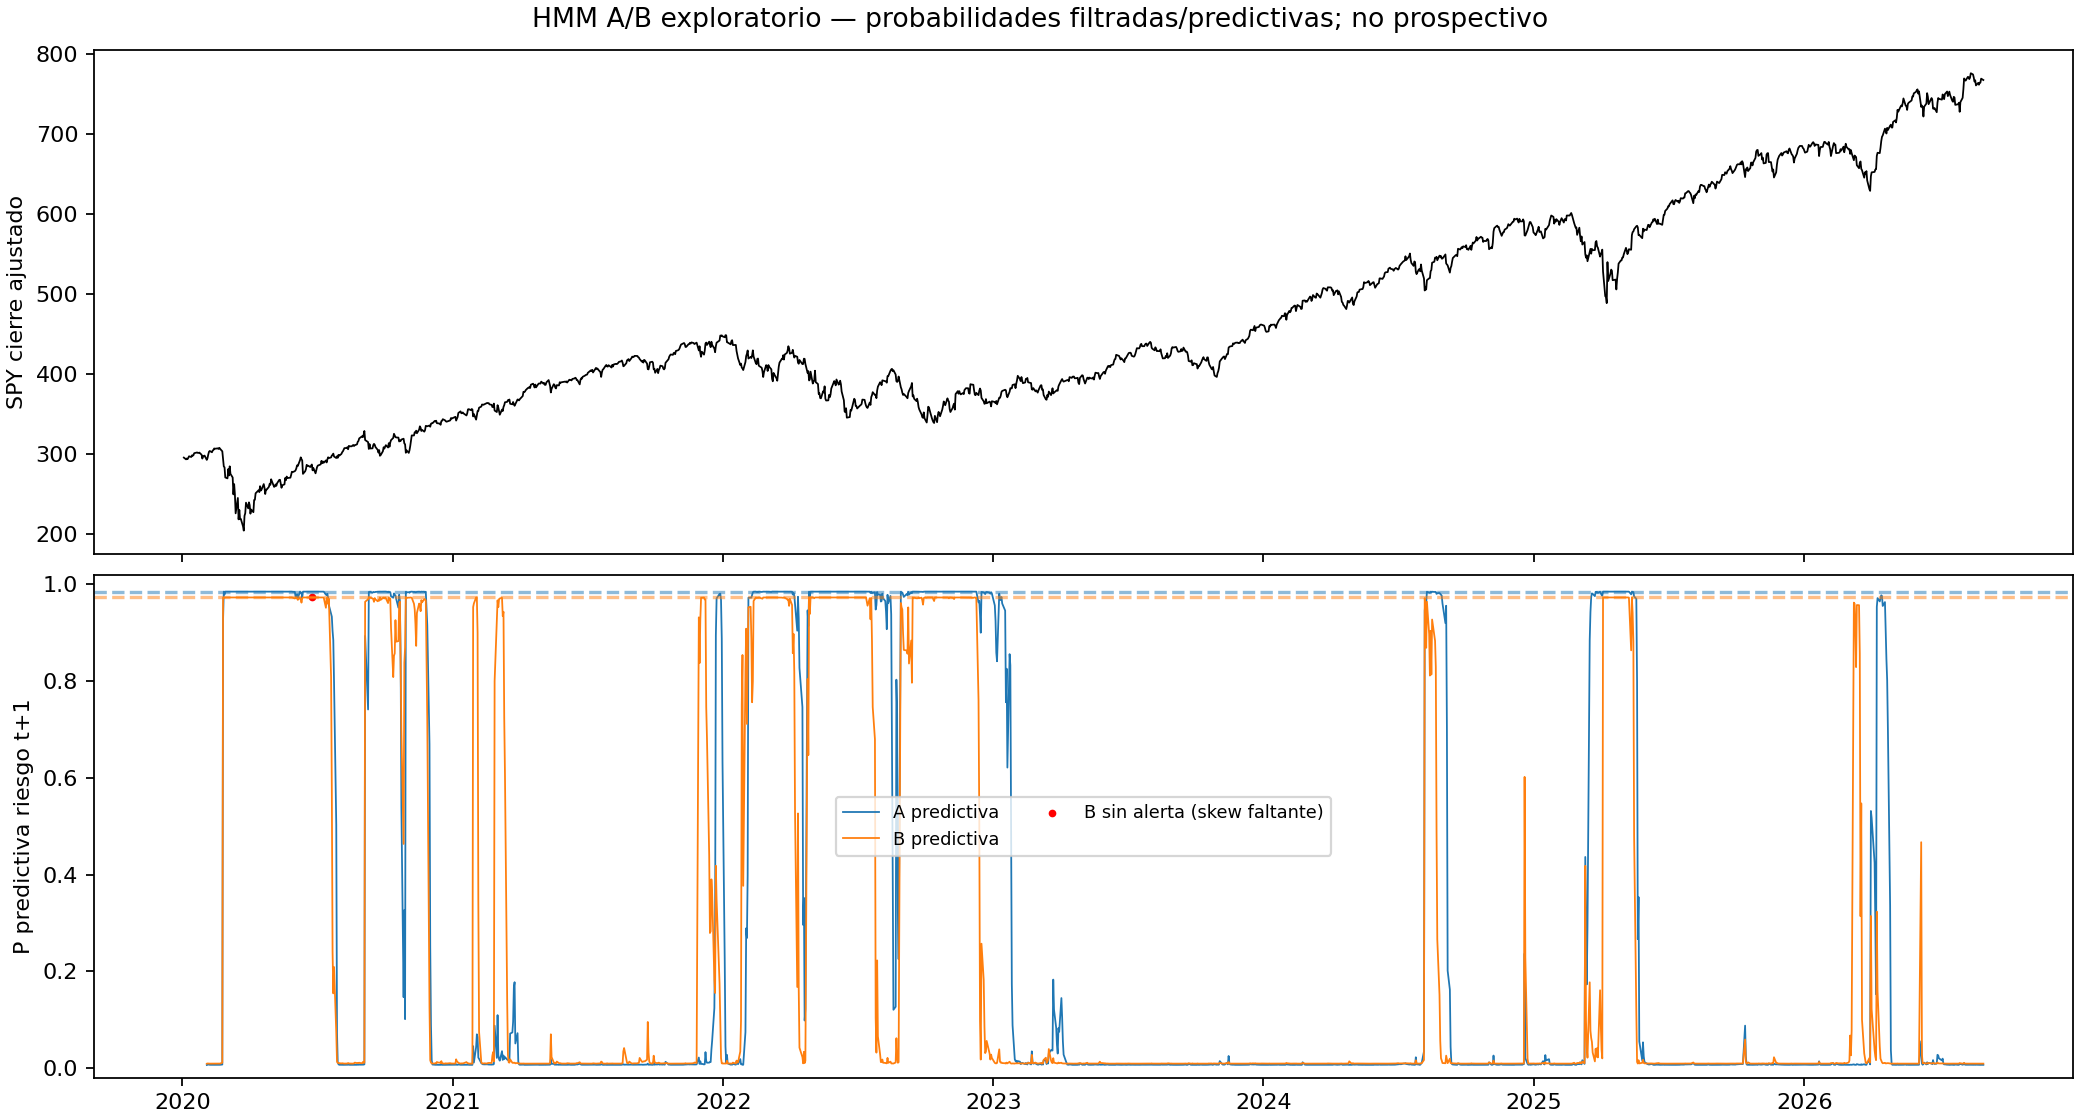

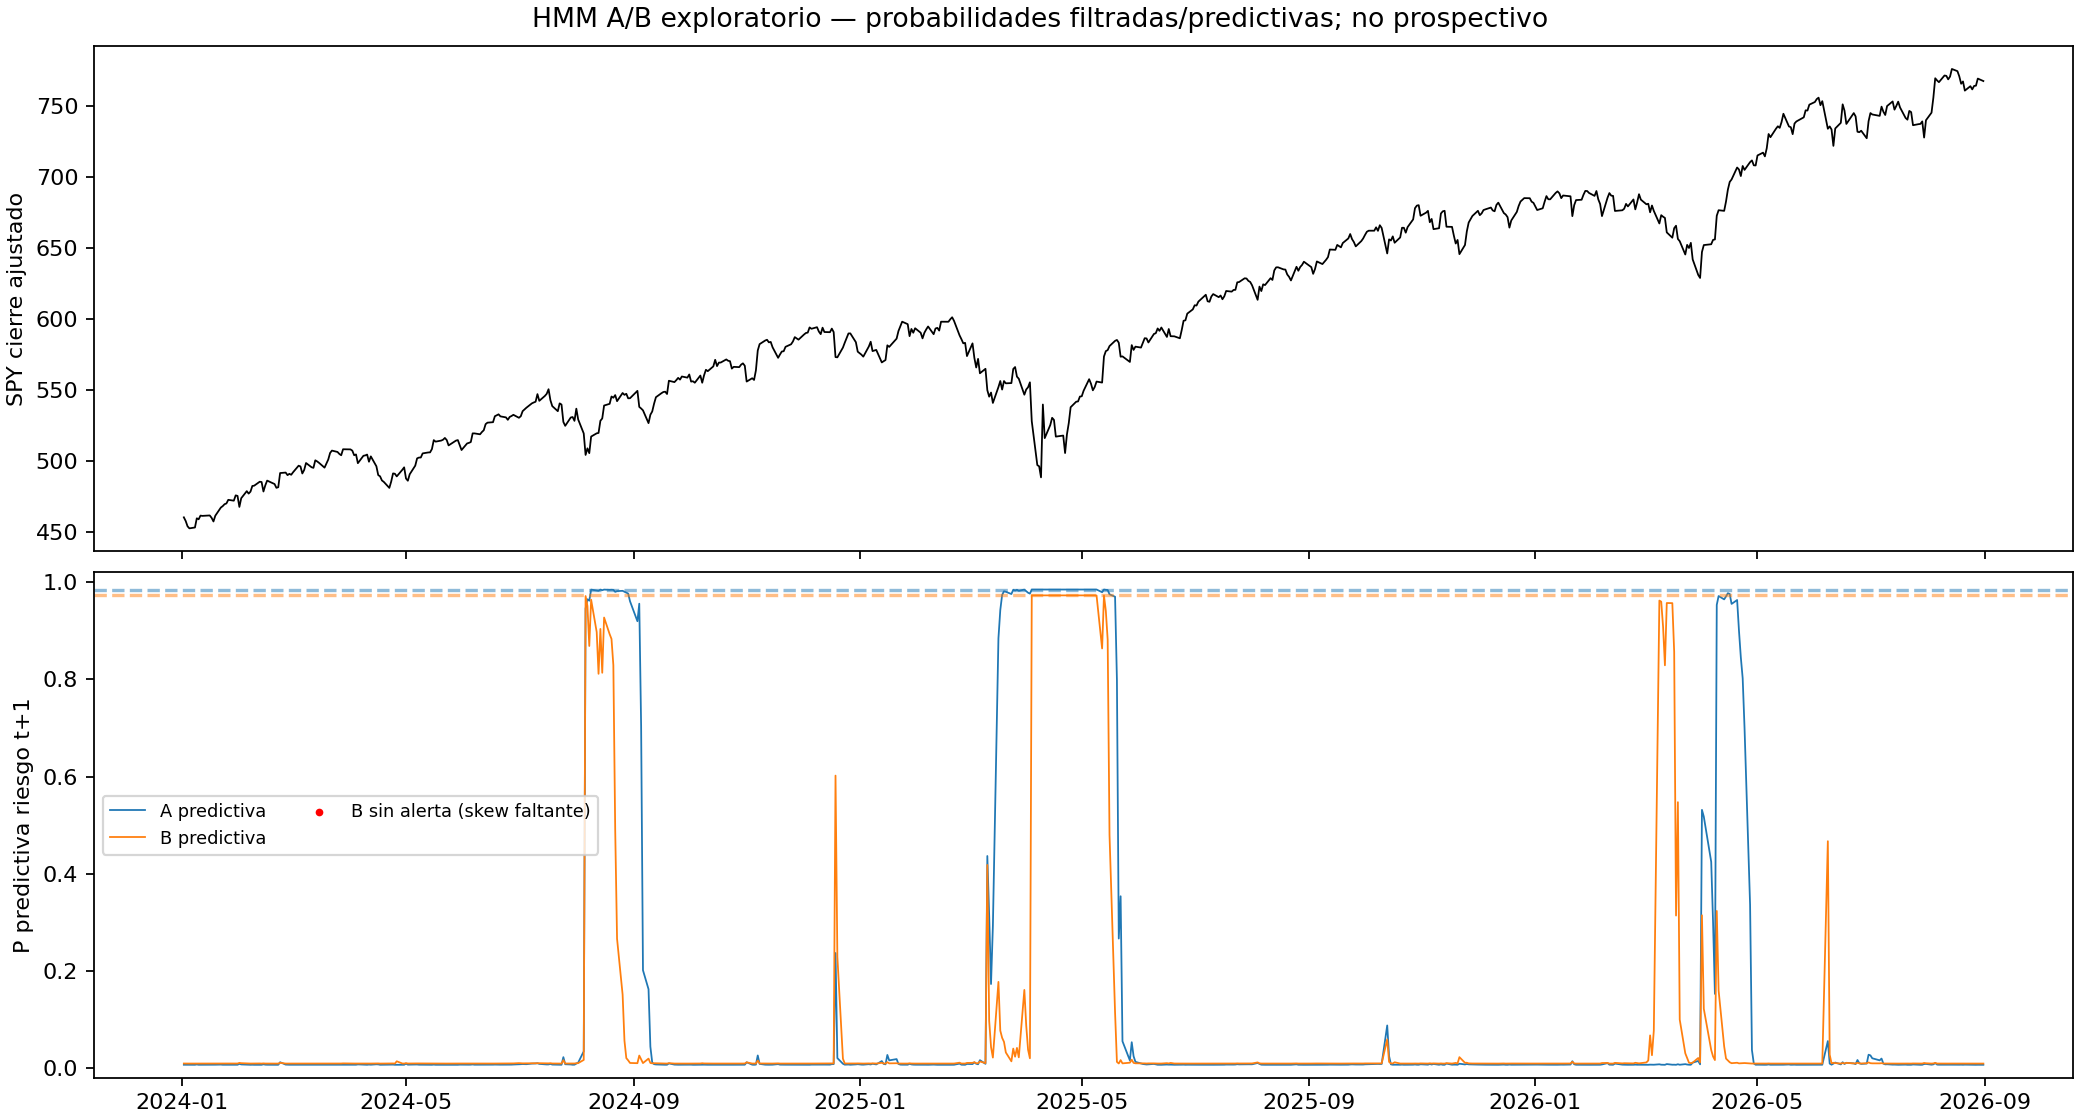

In [6]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS / 'hmm_ab_probabilities_full.png')))
display(Image(filename=str(REPORTS / 'hmm_ab_probabilities_seen_2024_2026.png'))) 

## 5. Episodios y alertas históricas

La brecha de cada decisión es la primera fecha de `d+1…d+20` cuyo cierre ajustado cae al menos 7% frente a `A_d`. Se deduplican fechas de brecha y se agrupan si quedan a cinco sesiones o menos. Para la frontera final se aplica la corrección: una alerta final solo se declara no acreditada tras observar sus cinco posibles inicios; cierres de episodio pueden quedar censurados.

In [7]:
episodes = pd.read_csv(REPORTS / 'hmm_ab_episodes.csv', parse_dates=['start','last_breach'])
metrics = pd.read_csv(REPORTS / 'hmm_ab_historical_metrics.csv')
common = pd.read_csv(REPORTS / 'hmm_ab_common_daily.csv', parse_dates=['decision_date'])
display(episodes)
display(metrics)
print('Fechas comunes A/B:', len(common), '| pérdidas B frente a A:', int(daily.A_alert_available.sum() - daily.B_alert_available.sum()))

,episode_id,start,last_breach,right_censored
0,1,2020-02-25,2020-02-27,False
1,2,2020-03-09,2020-03-20,False
2,3,2020-09-18,2020-09-23,False
3,4,2020-10-28,2020-10-28,False
4,5,2022-01-21,2022-01-27,False
5,6,2022-02-23,2022-02-23,False
6,7,2022-03-08,2022-03-08,False
7,8,2022-04-22,2022-04-29,False
8,9,2022-05-09,2022-05-11,False
9,10,2022-06-13,2022-06-16,False


,scope,model,decision_dates_evaluable,alerts,alert_frequency,episodes,episodes_right_censored,recall,credited_alerts,uncredited_alerts,TAAE
0,all_history_exploratory,A,1668,123,0.073741,17,0,0.176471,8,115,0.934959
1,all_history_exploratory,B,1668,123,0.073741,17,0,0.176471,9,114,0.926829
2,development_2020_2023,A,1005,99,0.098507,13,0,0.230769,8,91,0.919192
3,development_2020_2023,B,1005,99,0.098507,13,0,0.230769,9,90,0.909091
4,seen_2024_2026,A,663,24,0.036199,4,0,0.000000,0,24,1.000000
5,seen_2024_2026,B,663,24,0.036199,4,0,0.000000,0,24,1.000000
6,common_dates_all_history_exploratory,A,1647,123,0.074681,17,0,0.176471,8,115,0.934959
7,common_dates_all_history_exploratory,B,1647,123,0.074681,17,0,0.176471,9,114,0.926829


Fechas comunes A/B: 1652 | pérdidas B frente a A: 1


Interpretación y límite: recall, frecuencia y TAAE se muestran solo como descripción histórica. Los umbrales P90 se fijaron en desarrollo común, pero el ajuste de parámetros completo y el conocimiento previo de 2024–2026 impiden tratarlos como prueba prospectiva. Ninguna diferencia A/B demuestra utilidad económica, anticipación confirmada ni una alerta operativa.

## 6. Registro de fallos y cuestiones abiertas

- `hmmlearn` no está instalado; se usó un HMM gaussiano diagonal local con prueba sintética de faltantes. Requiere revisión independiente antes de una prueba confirmatoria.
- Se registraron advertencias de tipo de pandas en dos banderas A4; no hubo fallos de semillas ni cambios de datos.
- La disponibilidad de la cadena EOD antes de abrir `t+1` sigue siendo un supuesto no verificado.
- La implementación debe someterse a revisión de código adicional para un ensayo prospectivo congelado, incluyendo el tratamiento de censura de episodios.
- No se entrenó nada para Actinver, ni este análisis confirma desempeño prospectivo.